# What is the most optimal skill to learn for Data Analysts?

#### Methodology

1. Find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

## Import Libraries and Data

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Usuario\.conda\envs\da_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Clean Data

In [2]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"])

df_DA_US_exploded = df_DA_US.explode("job_skills")

df_DA_US_exploded.sample(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
479242,Data Analyst,Sustainability Data Analyst,"New York, NY",via Indeed,Full-time,False,"New York, United States",2023-06-07 13:59:58,False,False,United States,year,70087.0,NaN,NYC Careers,power bi,"{'analyst_tools': ['power bi', 'excel', 'word'..."
36578,Data Analyst,Compliance Data Analyst,"Manhattan, KS",via Indeed,Full-time,False,"Texas, United States",2023-09-16 13:02:46,False,False,United States,year,93027.0,NaN,NYC Careers,r,"{'analyst_tools': ['sas', 'power bi', 'spss', ..."
315568,Data Analyst,Marketing Data Analyst (Remote),Anywhere,via Talentify,Full-time,True,"New York, United States",2023-07-31 17:00:15,True,False,United States,year,89000.0,NaN,World Education Services,snowflake,"{'analyst_tools': ['tableau'], 'async': ['jira..."
598202,Data Analyst,Sr. Data Analyst,"St. Louis, MO",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-24 09:02:57,False,True,United States,year,97500.0,NaN,SteadyMD,python,"{'analyst_tools': ['looker', 'tableau'], 'prog..."
219386,Data Analyst,Data Analyst,"New York, NY",via Indeed,Full-time,False,"New York, United States",2023-02-15 21:59:56,True,True,United States,year,55000.0,NaN,ITN Networks,sql,"{'analyst_tools': ['excel', 'power bi'], 'prog..."


## Calculate Percent of Job Postings that Have Skills

In [5]:
df_DA_skills = df_DA_US_exploded.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)

df_DA_skills = df_DA_skills.rename(columns={"count":"skill_count", "median":"median_salary"})

DA_job_count = len(df_DA_US)

df_DA_skills["skill_percent"] = df_DA_skills["skill_count"] / DA_job_count * 100

skill_limit = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills["skill_percent"] > skill_limit]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


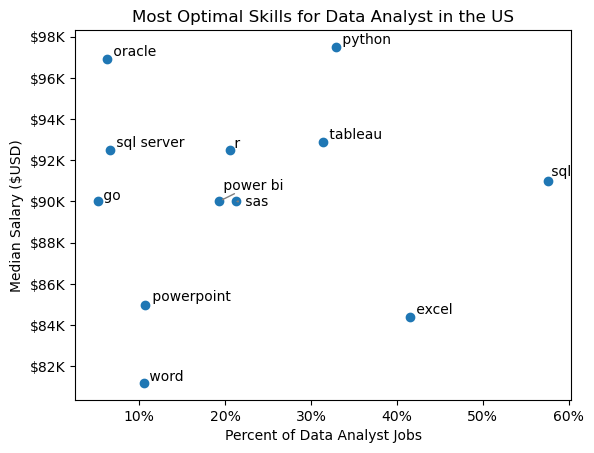

In [6]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_high_demand["skill_percent"], df_DA_skills_high_demand["median_salary"])
plt.xlabel("Percent of Data Analyst Jobs")
plt.ylabel("Median Salary ($USD)")
plt.title("Most Optimal Skills for Data Analyst in the US")

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

texts = []
for i,txt in enumerate(df_DA_skills_high_demand.index):
  texts.append(plt.text(df_DA_skills_high_demand["skill_percent"].iloc[i], df_DA_skills_high_demand["median_salary"].iloc[i], " " + txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray"))
plt.show()

In [10]:
df_technology = df["job_type_skills"].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
  row_dict = ast.literal_eval(row)
  for key,value in row_dict.items():
    if key in technology_dict:
      technology_dict[key] += value
    else:
      technology_dict[key] = value

for key,value in technology_dict.items():
  technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['dax',
  'powerbi',
  'cognos',
  'spss',
  'qlik',
  'ssis',
  'esquisse',
  'excel',
  'spreadsheet',
  'tableau',
  'nuix',
  'ms access',
  'looker',
  'power bi',
  'msaccess',
  'alteryx',
  'sap',
  'microstrategy',
  'sas',
  'visio',
  'datarobot',
  'splunk',
  'ssrs',
  'sharepoint',
  'powerpoint',
  'outlook',
  'sheets',
  'word'],
 'programming': ['solidity',
  't-sql',
  'dart',
  'clojure',
  'julia',
  'ocaml',
  'erlang',
  'golang',
  'assembly',
  'mongo',
  'nosql',
  'vba',
  'rust',
  'cobol',
  'scala',
  'bash',
  'kotlin',
  'f#',
  'c',
  'css',
  'groovy',
  'php',
  'javascript',
  'java',
  'haskell',
  'apl',
  'python',
  'ruby',
  'powershell',
  'fortran',
  'lisp',
  'delphi',
  'perl',
  'sas',
  'shell',
  'pascal',
  'sql',
  'go',
  'mongodb',
  'visual basic',
  'matlab',
  'c#',
  'sass',
  'c++',
  'typescript',
  'elixir',
  'visualbasic',
  'html',
  'swift',
  'lua',
  'no-sql',
  'vb.net',
  'objective-c',
  'r',
  'crys

Converts a dict into a pandas DF

In [11]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=["technology","skills"])

df_technology = df_technology.explode("skills")

df_technology

,technology,skills
0,analyst_tools,dax
0,analyst_tools,powerbi
0,analyst_tools,cognos
0,analyst_tools,spss
0,analyst_tools,qlik
...,...,...
9,sync,wire
9,sync,mattermost
9,sync,twilio
9,sync,slack


Merge df_DA_skills and df_technology baed on columns "job_skills" and "skills"

In [12]:
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on="job_skills", right_on="skills")

df_DA_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,100000.0,0.022989,libraries,theano
170,1,65000.0,0.022989,programming,typescript
171,1,147500.0,0.022989,cloud,vmware
172,1,65000.0,0.022989,webframeworks,vue


Filters `df_DA_skills_tech` to select rows where the 'percent' column exceeds a specified threshold, storing the result in `df_DA_skills_tech_high_demand`. 

In [13]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech["skill_percent"] > skill_limit]

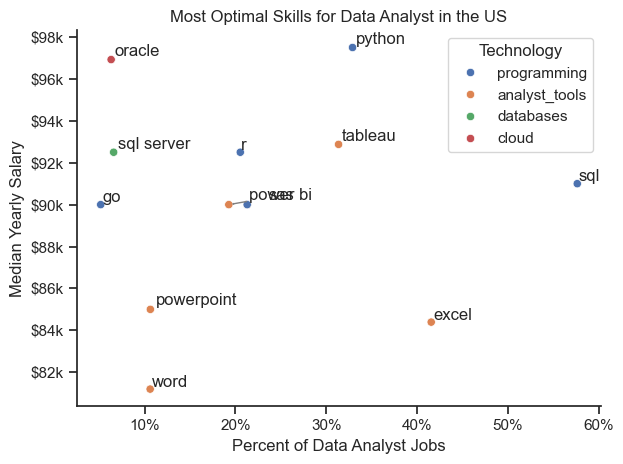

In [20]:
sns.scatterplot(
  data=df_DA_skills_tech_high_demand,
  x="skill_percent",
  y="median_salary",
  hue="technology"
)

sns.despine()
sns.set_theme(style="ticks")

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
  texts.append(plt.text(df_DA_skills_high_demand["skill_percent"].iloc[i], df_DA_skills_high_demand["median_salary"].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray"))

plt.xlabel("Percent of Data Analyst Jobs")
plt.ylabel("Median Yearly Salary")
plt.title("Most Optimal Skills for Data Analyst in the US")
plt.legend(title="Technology")

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}k"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()
